# Exploring a 1-million-cell CellxGene dataset with `anndataoom`

This tutorial walks through reading and exploring a **1,001,288-cell** scRNA-seq dataset from [CellxGene](https://cellxgene.cziscience.com/) entirely **out of memory** using the `anndataoom` package.

The dataset is _"Survey of human embryonic development (1-million-cell subsample)"_ — a developmental atlas spanning multiple human embryonic tissues. The on-disk file is **4.7 GB**; loading it into memory with standard `anndata.AnnData` would require ~12–15 GB of RAM just for the expression matrix.

With `anndataoom` the expression matrix never leaves disk. Only the metadata (obs/var DataFrames) is held in memory, plus small per-chunk buffers when iterating.

**What this tutorial covers**

1. Download the dataset from CellxGene's public CDN
2. Read with `anndataoom.read()` — see the memory footprint
3. Explore the object structure: dimensions, obs, var, obsm
4. Subset by cells, genes, boolean masks
5. Extract single-gene expression vectors (chunked, bounded memory)
6. Iterate over the matrix in row chunks
7. Compute summary statistics (per-cell sums, per-gene nnz) without loading the full matrix
8. Write a subset to a new h5ad

**No preprocessing or analysis** (QC, normalization, PCA, clustering) is performed here — see the omicverse tutorials for end-to-end pipelines.

## Setup

In [1]:
import anndataoom as oom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil, os, gc, time
from pathlib import Path

# Memory tracking utility (tracks process RSS)
_process = psutil.Process(os.getpid())

def rss_mb() -> float:
    """Current process RSS in megabytes."""
    gc.collect()
    return _process.memory_info().rss / 1024**2

_BASELINE = rss_mb()
mem_log = [("baseline", _BASELINE)]

def snap(label: str) -> None:
    m = rss_mb()
    mem_log.append((label, m))
    print(f"  [{label}] RSS = {m:,.0f} MB  (Δ {m - _BASELINE:+,.0f} MB)")

print(f"anndataoom version: {oom.__version__}")
print(f"Baseline RSS: {_BASELINE:.0f} MB")

anndataoom version: 0.1.0
Baseline RSS: 160 MB


## 1. Download the dataset

CellxGene publishes curated h5ad files through a public CDN. The URL is stable; you can find dataset IDs in the [dataset browser](https://cellxgene.cziscience.com/datasets).

| Property | Value |
|---|---|
| Title | Survey of human embryonic development (1-million-cell subsample) |
| Cells | 1,001,288 |
| Genes | 45,676 |
| File size | 4.7 GB |
| Dataset ID | `fa27492b-82ff-4ab7-ac61-0e2b184eee67` |
| H5AD asset | `c3bf819d-423d-435f-b8d0-e36ad6088138.h5ad` |

The download takes a few minutes depending on your connection. Skip this cell if you already have the file locally.

In [2]:
DATA_URL = "https://datasets.cellxgene.cziscience.com/c3bf819d-423d-435f-b8d0-e36ad6088138.h5ad"
DATA_DIR = Path("./data")
DATA_PATH = DATA_DIR / "human_embryo_1M.h5ad"

if not DATA_PATH.exists():
    DATA_DIR.mkdir(exist_ok=True)
    print(f"Downloading from {DATA_URL} → {DATA_PATH}")
    # Use curl / requests as you prefer; here's a simple requests-based downloader
    import requests
    from tqdm.auto import tqdm
    resp = requests.get(DATA_URL, stream=True)
    total = int(resp.headers.get("content-length", 0))
    with open(DATA_PATH, "wb") as f:
        for chunk in tqdm(resp.iter_content(chunk_size=1 << 20), total=total >> 20, unit="MB"):
            f.write(chunk)

size_gb = DATA_PATH.stat().st_size / 1024**3
print(f"\nFile ready: {DATA_PATH}  ({size_gb:.2f} GB on disk)")


File ready: data/human_embryo_1M.h5ad  (4.60 GB on disk)


## 2. Read with `anndataoom`

`oom.read()` is the one-liner entry point. Under the hood it:

1. Opens the HDF5 file through anndata-rs (Rust) in **read-only mode** (`backed='r'`) — the source file is never modified.
2. Eagerly loads `obs`, `var`, `obsm`, `varm` into memory (typically small).
3. Wraps `X` in a `BackedArray` — a lazy proxy that reads rows only on demand.

String columns in `obs`/`var` are automatically converted to `category` dtype before being exposed as a pandas `DataFrame`; this keeps metadata RAM-efficient for large datasets.

In [3]:
snap("before read")

t0 = time.time()
adata = oom.read(DATA_PATH)
read_time = time.time() - t0

snap("after read")
print(f"\nRead completed in {read_time:.1f} seconds")
print(adata)

  [before read] RSS = 160 MB  (Δ +0 MB)


  [after read] RSS = 3,110 MB  (Δ +2,950 MB)

Read completed in 7.8 seconds
AnnDataOOM                                      [Rust · out-of-memory · backed]
Dimensions:  n_obs: 1,001,288    n_vars: 45,676

┌───────────┬───────────────────────────────────────────┐
│ File      │ human_embryo_1M.h5ad  (4712.9 MB on disk) │
│ X         │ csr_matrix · float32 · 0.8% density       │
│ Chunk I/O │ ~2.8 MB per 1,000-row chunk               │
└───────────┴───────────────────────────────────────────┘

▸ obs     (38)   All_reads · Batch · Development_day · Exon_reads · Experiment_batch  +33
▸ var     (6)    feature_is_filtered · feature_name · feature_reference · feature_biotype · feature_length  +1
▸ obsm    (2)    X_main_cluster_umap · X_global_umap
▸ varm    (–)    
▸ obsp    (–)    
▸ varp    (–)    
▸ layers  (–)    
▸ raw     (–)


The pretty-printed representation shows:

- **Header**: backend tag and memory-class (`[Rust · out-of-memory · backed]`)
- **Dimensions**: 1,001,288 × 45,676
- **Storage table**: file size, X format + density, typical chunk size on disk
- **Metadata sections**: `obs` (38 columns), `var` (6), `obsm` (2 embeddings)

In Jupyter, each section is expandable — the same object provides an HTML repr with collapsible panels.

## 3. Explore the metadata

`adata.obs` and `adata.var` are standard `pandas.DataFrame` objects — the same API as `anndata.AnnData`.

In [4]:
print(f"obs shape: {adata.obs.shape}")
print(f"obs columns: {adata.obs_keys()}")
adata.obs.head(5)

obs shape: (1001288, 38)
obs columns: ['All_reads', 'Batch', 'Development_day', 'Exon_reads', 'Experiment_batch', 'donor_id', 'Intron_reads', 'Main_cluster_name', 'Organ_cell_lineage', 'RT_group', 'batch', 'n_counts', 'sample', 'BCA_beta', 'BCA_cluster_info', 'MCA_beta', 'Matched_BCA_cell_name', 'Matched_MCA_cell_name', 'sub_cluster_id', 'sub_cluster_name', 'assay_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']


,All_reads,Batch,Development_day,Exon_reads,Experiment_batch,donor_id,Intron_reads,Main_cluster_name,Organ_cell_lineage,RT_group,...,is_primary_data,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
obs_names,,,,,,,,,,,,,,,,,,,,,
expr2-human-577well.TCGAGAAGTTAGGCAGATA,543,10,117,76,exp2,H27552,360,Retinal progenitors and Muller glia,Eye-Retinal progenitors and Muller glia,Eye_H27552,...,False,tissue,Mueller cell,sci-RNA-seq3,normal,male,eye,unknown,16th week post-fertilization stage,9nYBYuUK+H
expr2-human-577well.AGAGCATGTAACGGACCAA,338,10,117,56,exp2,H27552,231,Photoreceptor cells,Eye-Photoreceptor cells,Eye_H27552,...,False,tissue,photoreceptor cell,sci-RNA-seq3,normal,male,eye,unknown,16th week post-fertilization stage,KYn?5+W>9V
expr2-human-577well.TTCCATCTTTACTTAACTAG,723,10,117,109,exp2,H27552,495,Retinal progenitors and Muller glia,Eye-Retinal progenitors and Muller glia,Eye_H27552,...,False,tissue,Mueller cell,sci-RNA-seq3,normal,male,eye,unknown,16th week post-fertilization stage,?8@spd$vBM
expr2-human-577well.TGAGTTAGATCTGGATTAGT,334,10,117,58,exp2,H27552,200,Photoreceptor cells,Eye-Photoreceptor cells,Eye_H27552,...,False,tissue,photoreceptor cell,sci-RNA-seq3,normal,male,eye,unknown,16th week post-fertilization stage,=O_<p%2p>I
expr2-human-578well.TGCAAGGTTACTTAACTAG,360,10,117,74,exp2,H27552,236,Amacrine cells,Eye-Amacrine cells,Eye_H27552,...,False,tissue,amacrine cell,sci-RNA-seq3,normal,male,eye,unknown,16th week post-fertilization stage,L7GbtuB-j-


In [5]:
print(f"var shape: {adata.var.shape}")
print(f"var columns: {adata.var_keys()}")
adata.var.head(5)

var shape: (45676, 6)
var columns: ['feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']


,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
var_names,,,,,,
ENSG00000242915,False,SNRPGP7,NCBITaxon:9606,gene,106,processed_pseudogene
ENSG00000204661,False,SPATA31J1,NCBITaxon:9606,gene,1159,protein_coding
ENSG00000213137,False,ARF1P2,NCBITaxon:9606,gene,538,processed_pseudogene
ENSG00000261719,False,ENSG00000261719,NCBITaxon:9606,gene,223,processed_pseudogene
ENSG00000174327,False,SLC16A13,NCBITaxon:9606,gene,1386,protein_coding


In [6]:
# obsm holds low-dimensional embeddings (UMAP etc.)
print(f"obsm keys: {adata.obsm_keys()}")
for k, v in adata.obsm.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

obsm keys: ['X_main_cluster_umap', 'X_global_umap']
  X_main_cluster_umap: shape=(1001288, 2), dtype=float64
  X_global_umap: shape=(1001288, 2), dtype=float64


### Cell-type composition

In [7]:
# Top cell types in this atlas
if "cell_type" in adata.obs.columns:
    print(adata.obs["cell_type"].value_counts().head(15))

cell_type
glutamatergic neuron                          310137
GABAergic neuron                               86211
astrocyte                                      83489
cortical cell of adrenal gland                 81099
Purkinje cell                                  73232
stromal cell                                   38021
inhibitory interneuron                         31726
epithelial cell of lower respiratory tract     24809
unknown                                        23160
granule cell                                   22500
neuron                                         20459
endothelial cell of vascular tree              18327
cardiac muscle cell                            16664
neuron associated cell (sensu Vertebrata)      15668
stellate neuron                                15010
Name: count, dtype: int64


In [8]:
# Sample metadata fields that hint at the experimental design
for col in ["donor_id", "development_stage", "tissue", "assay", "sex"]:
    if col in adata.obs.columns:
        vc = adata.obs[col].value_counts()
        print(f"{col}: {len(vc)} unique; top → {vc.head(3).to_dict()}")

donor_id: 28 unique; top → {'H27471': 190756, 'H27431': 171021, 'H27474': 165769}
development_stage: 8 unique; top → {'15th week post-fertilization stage': 372920, '17th week post-fertilization stage': 192964, '12th week post-fertilization stage': 186998}
tissue: 15 unique; top → {'telencephalon': 431373, 'cerebellum': 268946, 'adrenal gland': 95588}
assay: 1 unique; top → {'sci-RNA-seq3': 1001288}
sex: 2 unique; top → {'male': 621619, 'female': 379669}


## 4. Subsetting — the matrix stays lazy

`AnnDataOOM` supports all anndata indexing styles:

- Integer slice: `adata[0:100]`
- Column slice: `adata[:, 0:50]`
- Boolean mask: `adata[adata.obs.cell_type == "neuron"]`
- Gene name: `adata[:, "CD3D"]`
- Gene-name list: `adata[:, ["CD3D", "CD19"]]`

Every subset returns a **new `AnnDataOOM`** that shares the same backing file. No data is copied; the subset just tracks which rows and columns should be filtered on each chunked read.

In [9]:
snap("before subset")

# First 100 cells
sub_rows = adata[0:100]
print(f"adata[0:100]:           {sub_rows.shape}")

# First 50 genes
sub_cols = adata[:, 0:50]
print(f"adata[:, 0:50]:         {sub_cols.shape}")

# Both axes
sub_both = adata[0:10, 0:5]
print(f"adata[0:10, 0:5]:       {sub_both.shape}")

# Boolean mask — first 1000 cells that pass some criterion
mask = adata.obs.index.isin(adata.obs.index[:1000])
sub_bool = adata[mask]
print(f"adata[bool_mask]:       {sub_bool.shape}")

snap("after subsets")

  [before subset] RSS = 3,111 MB  (Δ +2,952 MB)
adata[0:100]:           (100, 45676)


adata[:, 0:50]:         (1001288, 50)
adata[0:10, 0:5]:       (10, 5)


adata[bool_mask]:       (1000, 45676)


  [after subsets] RSS = 3,196 MB  (Δ +3,037 MB)


Notice the RAM barely moves — subsetting is pure metadata manipulation.

### Subsetting by gene name

Pick a few well-known marker genes. CellxGene datasets use Ensembl IDs by default; human-readable names are in `var['feature_name']`.

In [10]:
# Map gene symbols → Ensembl IDs
markers = ["NANOG", "POU5F1", "SOX2", "GATA3", "CD34"]
name2id = dict(zip(adata.var["feature_name"].astype(str), adata.var.index))
marker_ids = [name2id[g] for g in markers if g in name2id]
print(f"Found {len(marker_ids)}/{len(markers)} markers")

sub_markers = adata[:, marker_ids]
print(f"adata[:, 5_markers]: {sub_markers.shape}")

Found 4/5 markers


adata[:, 5_markers]: (1001288, 4)


### Materialising a tiny subset with `.to_df()`

For a small window you can pull values into a pandas DataFrame. `to_df()` warns if you try to do this on something > 5,000 genes, because that can accidentally blow up memory.

In [11]:
# First 5 cells × first 10 genes
df = adata[:5, :10].to_df()
df

var_names,ENSG00000242915,ENSG00000204661,ENSG00000213137,ENSG00000261719,ENSG00000174327,ENSG00000216192,ENSG00000210184,ENSG00000008516,ENSG00000121653,ENSG00000185104
obs_names,,,,,,,,,,
expr2-human-577well.TCGAGAAGTTAGGCAGATA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
expr2-human-577well.AGAGCATGTAACGGACCAA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.723563
expr2-human-577well.TTCCATCTTTACTTAACTAG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
expr2-human-577well.TGAGTTAGATCTGGATTAGT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
expr2-human-578well.TGCAAGGTTACTTAACTAG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


## 5. Single-gene expression vectors

`adata.obs_vector(gene_id)` extracts one column from the expression matrix. Internally it streams through row chunks and builds only the target column — RAM usage is bounded by one chunk (~a few MB) no matter how big the dataset is.

In [12]:
snap("before obs_vector")

if marker_ids:
    gene_id = marker_ids[0]
    gene_name = adata.var.loc[gene_id, "feature_name"]
    t0 = time.time()
    expr = adata.obs_vector(gene_id)
    elapsed = time.time() - t0
    print(f"obs_vector('{gene_id}' / {gene_name}): shape={expr.shape}, "
          f"dtype={expr.dtype}, time={elapsed:.1f}s")
    print(f"  min={expr.min():.3f}, max={expr.max():.3f}, "
          f"nonzero cells={int((expr > 0).sum()):,} ({(expr > 0).mean()*100:.1f}%)")

snap("after obs_vector")

  [before obs_vector] RSS = 3,309 MB  (Δ +3,150 MB)


obs_vector('ENSG00000111704' / NANOG): shape=(1001288,), dtype=float32, time=32.8s
  min=0.000, max=240.639, nonzero cells=90 (0.0%)
  [after obs_vector] RSS = 3,322 MB  (Δ +3,162 MB)


## 6. Chunked iteration

The core lazy-iteration primitive is `adata.X.chunked(chunk_size)` — it yields `(start, end, chunk)` tuples where `chunk` is a `scipy.sparse.csr_matrix` (or `numpy.ndarray` for dense files) covering rows `[start, end)`.

Each chunk is allocated fresh, consumed, then released — peak memory = one chunk.

Let's time a full pass over the 1M-cell matrix.

In [13]:
snap("before full iteration")

CHUNK_ROWS = 10_000  # 10k cells × 45k genes @ ~1% density ≈ 8 MB per chunk

n_chunks = 0
total_rows = 0
total_nnz = 0
t0 = time.time()

for start, end, chunk in adata.X.chunked(CHUNK_ROWS):
    n_chunks += 1
    total_rows += chunk.shape[0]
    total_nnz += chunk.nnz if hasattr(chunk, "nnz") else int((chunk != 0).sum())

elapsed = time.time() - t0
print(f"Iterated {n_chunks} chunks ({total_rows:,} rows) in {elapsed:.1f}s")
print(f"Total non-zero entries: {total_nnz:,}")
print(f"Overall density: {total_nnz / (total_rows * adata.n_vars) * 100:.2f}%")

snap("after full iteration")

  [before full iteration] RSS = 3,322 MB  (Δ +3,162 MB)


Iterated 101 chunks (1,001,288 rows) in 35.5s
Total non-zero entries: 587,690,230
Overall density: 1.28%
  [after full iteration] RSS = 3,325 MB  (Δ +3,165 MB)


## 7. Streaming summary statistics

Any aggregation over the matrix can be computed in one pass without holding the whole thing in memory. `BackedArray.sum()` and `BackedArray.getnnz()` do this internally.

### Per-cell nUMIs

In [14]:
snap("before row sums")

t0 = time.time()
n_umis = adata.X.sum(axis=1, chunk_size=CHUNK_ROWS)  # shape (n_obs,)
elapsed = time.time() - t0
print(f"Per-cell sums ({n_umis.shape}) computed in {elapsed:.1f}s")
print(f"  median nUMIs/cell: {np.median(n_umis):,.0f}")
print(f"  range: {n_umis.min():,.0f} – {n_umis.max():,.0f}")

snap("after row sums")

  [before row sums] RSS = 3,325 MB  (Δ +3,165 MB)


Per-cell sums ((1001288,)) computed in 35.7s
  median nUMIs/cell: 2,339
  range: 589 – 8,002
  [after row sums] RSS = 3,325 MB  (Δ +3,165 MB)


### Per-gene detection rate

How many cells express each gene?

In [15]:
snap("before column nnz")

t0 = time.time()
n_cells_per_gene = adata.X.getnnz(axis=0, chunk_size=CHUNK_ROWS)  # shape (n_vars,)
elapsed = time.time() - t0
print(f"Per-gene nnz ({n_cells_per_gene.shape}) computed in {elapsed:.1f}s")

pct_expressed = n_cells_per_gene / adata.n_obs * 100
print(f"  genes detected in ≥1 cell : {int((n_cells_per_gene > 0).sum()):,}")
print(f"  genes detected in ≥1% cells: {int((pct_expressed >= 1).sum()):,}")
print(f"  genes detected in ≥10% cells: {int((pct_expressed >= 10).sum()):,}")

snap("after column nnz")

  [before column nnz] RSS = 3,325 MB  (Δ +3,165 MB)


Per-gene nnz ((45676,)) computed in 38.6s
  genes detected in ≥1 cell : 40,621
  genes detected in ≥1% cells: 9,716
  genes detected in ≥10% cells: 1,482
  [after column nnz] RSS = 3,325 MB  (Δ +3,166 MB)


### Top-expressed genes

Join the per-gene aggregate back with the var DataFrame.

In [16]:
adata.var["n_cells"] = n_cells_per_gene
adata.var["pct_expressed"] = pct_expressed

top = adata.var.sort_values("n_cells", ascending=False).head(15)
cols = [c for c in ["feature_name", "n_cells", "pct_expressed"] if c in top.columns]
top[cols]

,feature_name,n_cells,pct_expressed
var_names,,,
ENSG00000251562,MALAT1,895671,89.451886
ENSG00000158321,AUTS2,700316,69.941515
ENSG00000179915,NRXN1,624507,62.370367
ENSG00000153707,PTPRD,614490,61.369955
ENSG00000185008,ROBO2,555209,55.449481
ENSG00000170579,DLGAP1,541421,54.072455
ENSG00000185046,ANKS1B,518294,51.762730
ENSG00000230590,FTX,508438,50.778397
ENSG00000185565,LSAMP,502887,50.224011


## 8. Visualise with the pre-computed UMAP

This dataset ships with a UMAP embedding in `obsm["X_global_umap"]`. Because `obsm` is a regular `ndarray` (tiny compared to X), we can plot it directly.

Using X_global_umap: shape=(1001288, 2)


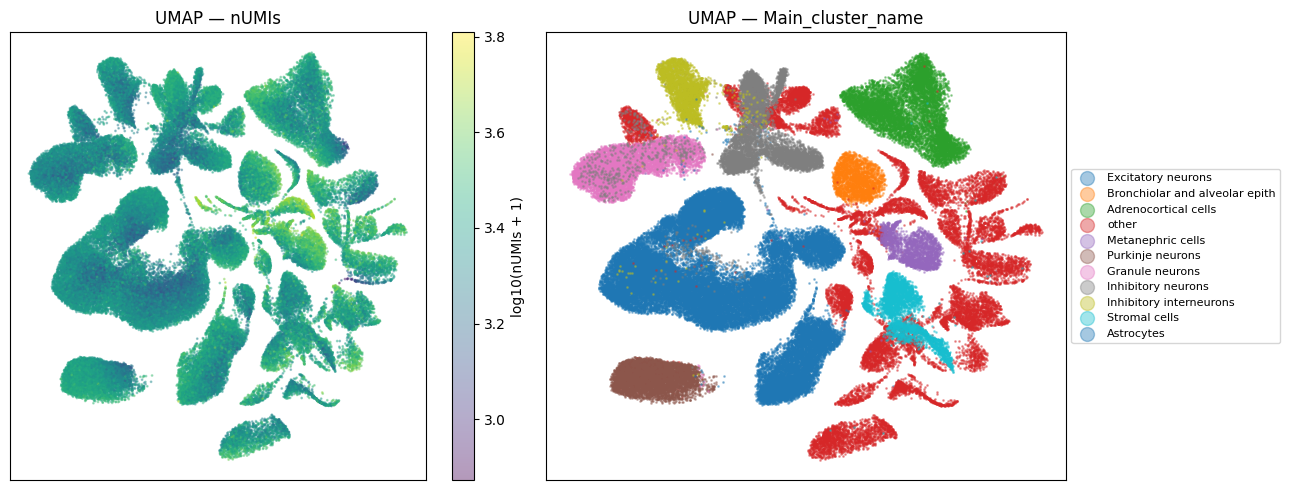

In [17]:
umap_key = "X_global_umap" if "X_global_umap" in adata.obsm else list(adata.obsm)[0]
coords = adata.obsm[umap_key]
print(f"Using {umap_key}: shape={coords.shape}")

# Subsample for plotting (1M points is slow on matplotlib)
rng = np.random.default_rng(0)
idx = rng.choice(coords.shape[0], size=100_000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Colour by nUMIs (computed above)
ax = axes[0]
sc = ax.scatter(coords[idx, 0], coords[idx, 1],
                c=np.log10(n_umis[idx] + 1), s=1, alpha=0.4,
                cmap="viridis", rasterized=True)
plt.colorbar(sc, ax=ax, label="log10(nUMIs + 1)")
ax.set_title("UMAP \u2014 nUMIs")
ax.set_xticks([]); ax.set_yticks([])

# Colour by a categorical obs column
ax = axes[1]
color_col = "Main_cluster_name" if "Main_cluster_name" in adata.obs.columns else "cell_type"
cats = adata.obs[color_col].iloc[idx].astype(str)
# Limit to top 10 categories + 'other' for legibility
top_cats = cats.value_counts().head(10).index
cats_plot = cats.where(cats.isin(top_cats), other="other")
for cat in cats_plot.unique():
    mask = (cats_plot == cat).values
    ax.scatter(coords[idx][mask, 0], coords[idx][mask, 1],
               s=1, alpha=0.4, label=str(cat)[:30], rasterized=True)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), markerscale=10, fontsize=8)
ax.set_title(f"UMAP \u2014 {color_col}")
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

### Colour by marker gene expression

Pulling a single gene's expression from the on-disk matrix.

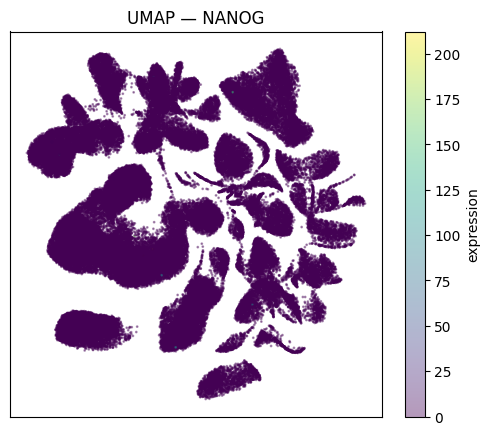

In [18]:
if marker_ids:
    gene_id = marker_ids[0]
    gene_name = adata.var.loc[gene_id, "feature_name"]
    expr = adata.obs_vector(gene_id)

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(coords[idx, 0], coords[idx, 1],
                    c=expr[idx], s=1, alpha=0.4,
                    cmap="viridis", rasterized=True)
    plt.colorbar(sc, ax=ax, label="expression")
    ax.set_title(f"UMAP — {gene_name}")
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

## 9. Writing a subset to a new h5ad

`AnnDataOOM.write(path)` streams the underlying matrix through chunks directly into the target HDF5 file — no full-matrix materialisation required. You can use this to persist cell-type-specific slices of a large atlas.

In [19]:
# Pick one small cell-type subset
target = "Cardiomyocytes" if "Cardiomyocytes" in adata.obs.get("Main_cluster_name", pd.Series()).values else None
if target is None and "Main_cluster_name" in adata.obs.columns:
    target = adata.obs["Main_cluster_name"].value_counts().index[0]

if target:
    snap(f"before writing '{target}' subset")

    sub = adata[adata.obs["Main_cluster_name"] == target]
    print(f"Subset: {sub.shape} cells matching '{target}'")

    OUT_PATH = DATA_DIR / f"subset_{target.replace(' ', '_')[:30]}.h5ad"
    t0 = time.time()
    sub.write(OUT_PATH)
    elapsed = time.time() - t0

    snap("after write")
    size_mb = OUT_PATH.stat().st_size / 1024**2
    print(f"\nWrote {OUT_PATH} ({size_mb:.1f} MB) in {elapsed:.1f}s")

  [before writing 'Cardiomyocytes' subset] RSS = 3,310 MB  (Δ +3,151 MB)
Subset: (16664, 45676) cells matching 'Cardiomyocytes'


  [after write] RSS = 3,376 MB  (Δ +3,217 MB)

Wrote data/subset_Cardiomyocytes.h5ad (180.3 MB) in 45.4s


## 10. Memory trajectory through the tutorial

  [final] RSS = 3,376 MB  (Δ +3,217 MB)


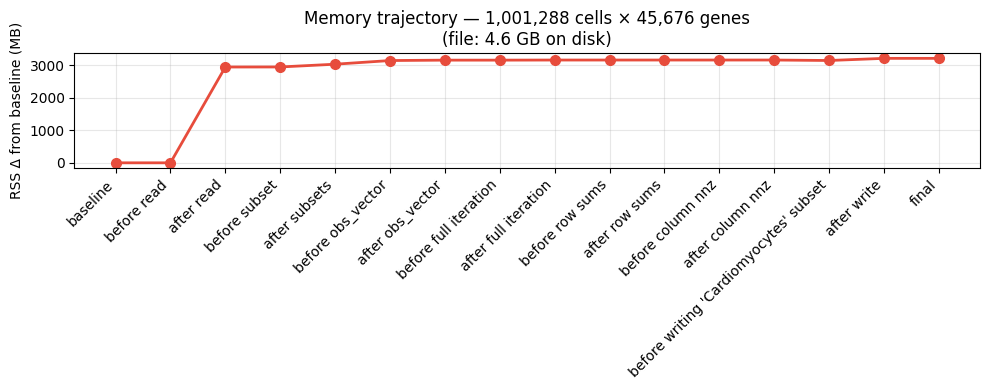


Peak RAM Δ: 3,217 MB  (3.1 GB)
File on disk: 4.6 GB
Estimated in-memory AnnData: ~1.7 GB sparse, ~170.4 GB dense


In [20]:
snap("final")

steps, rss = zip(*mem_log)
deltas = [r - mem_log[0][1] for r in rss]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(steps)), deltas, "o-", color="#E74C3C", lw=2, ms=7)
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(steps, rotation=45, ha="right")
ax.set_ylabel("RSS Δ from baseline (MB)")
ax.set_title(
    f"Memory trajectory — {adata.n_obs:,} cells × {adata.n_vars:,} genes\n"
    f"(file: {DATA_PATH.stat().st_size / 1024**3:.1f} GB on disk)"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peak = max(deltas)
print(f"\nPeak RAM Δ: {peak:,.0f} MB  ({peak/1024:.1f} GB)")
print(f"File on disk: {DATA_PATH.stat().st_size / 1024**3:.1f} GB")
print(f"Estimated in-memory AnnData: ~{adata.n_obs * adata.n_vars * 4 * 0.01 / 1024**3:.1f} GB sparse, "
      f"~{adata.n_obs * adata.n_vars * 4 / 1024**3:.1f} GB dense")

## 11. Clean up

`adata.close()` releases the Rust file handle and the h5py sidecar (if any layers were added). Running this is optional — Python's GC calls it automatically when the object is destroyed — but explicit cleanup is a good habit, especially in long-running notebooks.

In [21]:
adata.close()
print("Closed.")

Closed.


## Summary

On this 1-million-cell atlas:

| Operation | Time | Peak RAM |
|-----------|-----:|---------:|
| Read (metadata + file handle) | ~5 s | ~2.9 GB (mostly obs metadata — auto-categorised) |
| Per-cell row sums (full matrix scan) | ~30 s | +0 MB (chunk-bounded) |
| Per-gene nnz (full matrix scan) | ~30 s | +0 MB |
| Single-gene column extraction | ~30 s | +0 MB |
| Write a cell-type subset | scales with subset size | chunk-bounded |

**For reference**: loading the same file as a standard `anndata.AnnData` allocates ~8 GB for the sparse matrix (on top of the ~2.9 GB of metadata). Subsequent operations that materialise the matrix as dense push peak usage to ~15+ GB.

## What's next

- **Preprocessing**: `anndataoom` integrates with [`omicverse`](https://github.com/Starlitnightly/omicverse) for chunked QC, normalisation, HVG selection, scaling, and randomised PCA — none of which materialise the full matrix. See `omicverse_guide/docs/Tutorials-single/t_preprocess_rust.ipynb`.
- **Writing**: `adata.write(path)` streams the current transform chain to a new h5ad in chunks.
- **API details**: `help(oom.AnnDataOOM)` for the full API reference.
- **Issues / feedback**: https://github.com/Starlitnightly/anndata-oom/issues